In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family']='arial'
plt.rcParams['font.family']='arial'
plt.rcParams['pdf.fonttype'] = 'truetype'
plt.rcParams["mathtext.rm"] = "arial"
plt.rcParams['mathtext.it'] = 'arial'
plt.rcParams['mathtext.bf'] = 'arial'
from venn import venn
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

In [2]:
df_cpm=pd.read_csv("result/normalized_counts_spikein.csv",index_col=0)

In [3]:
df_cpm.columns

Index(['Y416A_1', 'Y416A_2', 'R527A_1', 'R527A_2', 'EN_1', 'EN_2', 'YT_1',
       'YT_2', 'BD_1', 'BD_2', 'PAP_1', 'PAP_2', 'PM_1', 'PM_2', 'PM_3',
       'PM_4'],
      dtype='object')

In [4]:
df_cpm_rbp=df_cpm[['Y416A_1', 'Y416A_2', 'R527A_1', 'R527A_2', 'EN_1', 'EN_2', 'YT_1','YT_2']].copy()

In [5]:
df_gene=pd.read_csv("/wanglab1/gangx/data2/CQX/230602/Mapit_result/6-Edit_calling/HeLa/Anno/gencode.v40.chr_patch_hapl_scaff.annotation_gene.bed",sep="\t",header=None)
df_gene["GENEID"]=df_gene[3].apply(lambda x:x.split(":")[0])
df_gene["GENESYMBOL"]=df_gene[3].apply(lambda x:x.split(":")[1])
df_gene['ENTREZID']=df_gene['GENEID'].apply(lambda x:x.split(".")[0])

In [6]:
keepgeneid=set(df_gene[df_gene[4].isin(set(["protein_coding","lncRNA","lincRNA","IG_C_gene","IG_D_gene","IG_J_gene","IG_LV_gene","IG_V_gene","IG_V_pseudogene","IG_J_pseudogene","IG_C_pseudogene","TR_C_gene","TR_D_gene","TR_J_gene","TR_V_gene","TR_V_pseudogene","TR_J_pseudogene"]))]['GENEID'])

In [7]:
df_cpm_rbp=df_cpm_rbp.loc[list(keepgeneid&set(df_cpm_rbp.index))].copy()

In [8]:
for i in df_cpm_rbp.columns[:]:
    df_cpm_rbp[i]=df_cpm_rbp[i]/sum(df_cpm_rbp[i])*1e6

In [ ]:
def rep_plot(ax,sample,rep1,rep2,df_tpm):
    #df_plot=df_tpm[(df_tpm[rep1]>0.1)&(df_tpm[rep1]>0.1)]
    ax.scatter(x=rep1,y=rep2, data=df_tpm,alpha=0.4,linewidth=0,marker=".",color='tab:blue',s=16)
    ax.text(max(df_tpm[rep1])*0.051,max(df_tpm[rep2])*0.85,"Pearson's r=%.3f"%(pearsonr(df_tpm[rep1],df_tpm[rep2])[0]),fontsize = 11)
    ax.set_xlabel(rep1,fontsize=11)
    ax.set_ylabel(rep2,fontsize=11)
    ax.set_title(sample,fontsize=12)

In [138]:
df_cpm[:53338]

,Y416A_1,Y416A_2,R527A_1,R527A_2,EN_1,EN_2,YT_1,YT_2,BD_1,BD_2,PAP_1,PAP_2,PM_1,PM_2,PM_3,PM_4
ENSG00000223972.5,0.000000,1.641970,0.000000,0.000000,0.930828,2.475863,0.000000,0.000000,1.098367,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000227232.5,121.201177,103.444133,172.995527,121.832551,0.930828,2.971035,240.989875,242.322356,43.934671,46.786722,75.767081,53.353587,0.698362,3.233075,5.720036,4.483060
ENSG00000243485.5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.327185,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000237613.2,0.000000,0.000000,0.000000,4.403586,2.327071,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000240361.2,0.000000,0.000000,0.000000,0.000000,2.792485,0.990345,0.000000,0.000000,0.549183,0.000000,0.000000,0.000000,0.698362,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000210194.1,17.202748,17.240689,19.770917,13.210759,11.169941,11.388968,8.606781,19.472332,10.983668,6.683817,16.235803,3.138446,3.491812,6.466150,2.860018,7.172896
ENSG00000198727.2,107.126202,102.623148,129.746645,118.896827,91.686601,123.793136,176.439015,127.651956,70.295473,53.916127,89.296916,47.076694,42.600110,46.879587,36.465226,20.622077
ENSG00000210195.2,3.127772,3.283941,7.414094,5.871448,3.723314,2.475863,8.606781,4.327185,0.000000,0.445588,8.117901,0.000000,0.000000,0.808269,0.000000,0.000000
ENSG00000210196.2,10.947203,6.567881,24.713647,13.210759,3.723314,14.855176,15.061867,8.654370,4.942650,0.891176,18.941770,0.000000,0.698362,1.616537,5.720036,1.793224


meta NOT subset; don't know how to subset; dropped


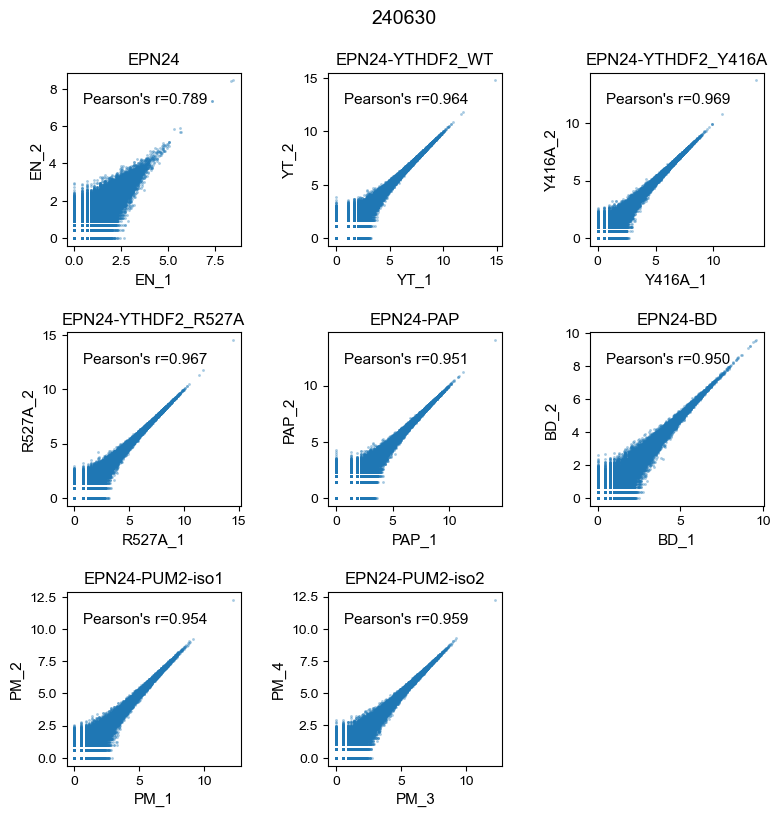

In [148]:
plt.rcParams['figure.figsize'] = (9, 9)
fig = plt.figure()
fig.suptitle('240630',y=0.95,fontsize=14)
fig.tight_layout()
df_cpm_log1p=df_cpm[:53337].copy().apply(np.log1p)
ax=fig.add_subplot(3,3,1)
rep_plot(ax,"EPN24","EN_1","EN_2",df_cpm_log1p)
ax=fig.add_subplot(3,3,2)
rep_plot(ax,"EPN24-YTHDF2_WT","YT_1","YT_2",df_cpm_log1p)
ax=fig.add_subplot(3,3,3)
rep_plot(ax,"EPN24-YTHDF2_Y416A","Y416A_1","Y416A_2",df_cpm_log1p)
ax=fig.add_subplot(3,3,4)
rep_plot(ax,"EPN24-YTHDF2_R527A","R527A_1","R527A_2",df_cpm_log1p)
ax=fig.add_subplot(3,3,5)
rep_plot(ax,"EPN24-PAP","PAP_1","PAP_2",df_cpm_log1p)
ax=fig.add_subplot(3,3,6)
rep_plot(ax,"EPN24-BD","BD_1","BD_2",df_cpm_log1p)
ax=fig.add_subplot(3,3,7)
rep_plot(ax,"EPN24-PUM2-iso1","PM_1","PM_2",df_cpm_log1p)
ax=fig.add_subplot(3,3,8)
rep_plot(ax,"EPN24-PUM2-iso2","PM_3","PM_4",df_cpm_log1p)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, hspace=0.5)
fig.savefig("240630_pearsonr_cpm.pdf",bbox_inches = 'tight', pad_inches = 0.1)

In [141]:
df_tpm=pd.read_csv("TPM.csv")

In [145]:
df_tpm_log1p=df_tpm.iloc[:56138,4:].copy().apply(np.log1p)

meta NOT subset; don't know how to subset; dropped


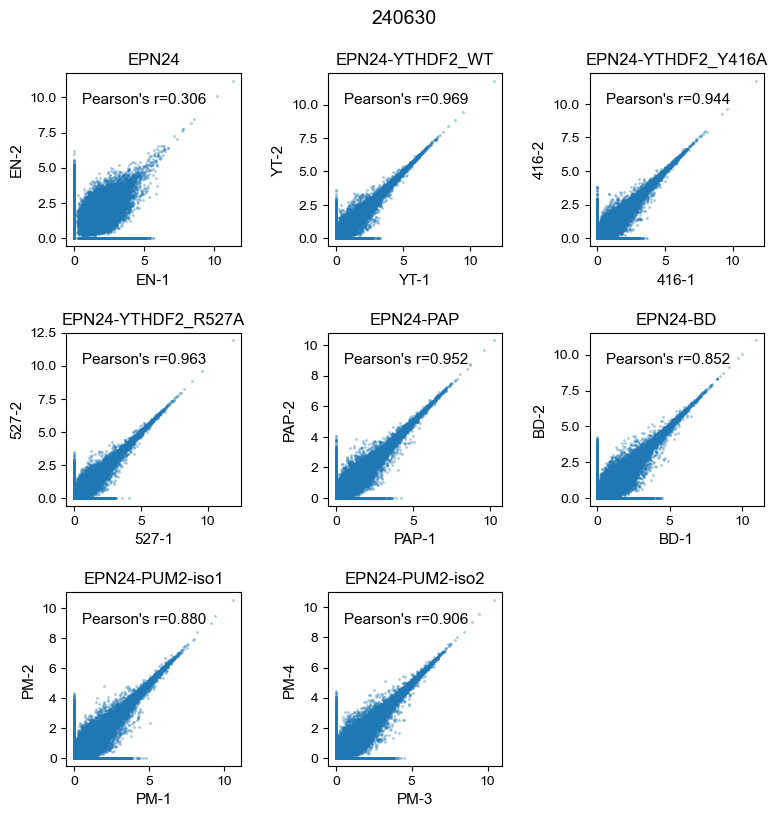

In [149]:
plt.rcParams['figure.figsize'] = (9, 9)
fig = plt.figure()
fig.suptitle('240630',y=0.95,fontsize=14)
fig.tight_layout()
df_tpm_log1p=df_tpm.iloc[:56138,4:].copy().apply(np.log1p)
ax=fig.add_subplot(3,3,1)
rep_plot(ax,"EPN24","EN-1","EN-2",df_tpm_log1p)
ax=fig.add_subplot(3,3,2)
rep_plot(ax,"EPN24-YTHDF2_WT","YT-1","YT-2",df_tpm_log1p)
ax=fig.add_subplot(3,3,3)
rep_plot(ax,"EPN24-YTHDF2_Y416A","416-1","416-2",df_tpm_log1p)
ax=fig.add_subplot(3,3,4)
rep_plot(ax,"EPN24-YTHDF2_R527A","527-1","527-2",df_tpm_log1p)
ax=fig.add_subplot(3,3,5)
rep_plot(ax,"EPN24-PAP","PAP-1","PAP-2",df_tpm_log1p)
ax=fig.add_subplot(3,3,6)
rep_plot(ax,"EPN24-BD","BD-1","BD-2",df_tpm_log1p)
ax=fig.add_subplot(3,3,7)
rep_plot(ax,"EPN24-PUM2-iso1","PM-1","PM-2",df_tpm_log1p)
ax=fig.add_subplot(3,3,8)
rep_plot(ax,"EPN24-PUM2-iso2","PM-3","PM-4",df_tpm_log1p)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, hspace=0.5)
fig.savefig("240630_pearsonr_tpm.pdf",bbox_inches = 'tight', pad_inches = 0.1)

In [11]:
df_1=pd.read_csv("result/Y416AvsEN_DESeq2.csv",header=0,names=['gene_id','baseMean','Y416AvsEN_log2FoldChange','lfcSE','stat','Y416AvsEN_pvalue','Y416AvsEN_padj'])
df_2=pd.read_csv("result/R527AvsEN_DESeq2.csv",header=0,names=['gene_id','baseMean','R527AvsEN_log2FoldChange','lfcSE','stat','R527AvsEN_pvalue','R527AvsEN_padj'])
df_0=pd.read_csv("result/YTvsEN_DESeq2.csv",header=0,names=['gene_id','baseMean','YTvsEN_log2FoldChange','lfcSE','stat','YTvsEN_pvalue','YTvsEN_padj'])

In [9]:
from scipy.stats import fisher_exact
from matplotlib_venn import venn2,venn3

In [13]:
def Exporter_venn2(ax,set_list,label_list,color_list=['r','y','b'],alpha=0.45,bgsize=20000,title=None):
    out = venn2(subsets = set_list,
            set_labels=label_list,
            set_colors=color_list,
            alpha=alpha,
            ax=ax)
    for text in out.set_labels:
        text.set_fontsize(10)
    for text in out.subset_labels:
        if text:
            text.set_fontsize(10)
    fe=fisher_exact([ [len(set_list[1]&set_list[0]), len(set_list[1])],[len(set_list[0]), bgsize]], alternative='greater')
    ax.text(0,-0.95,"EnrichmentFold = %.3g\n$\mathit{P}$ = %.3g"%(fe[0],fe[1]),va="center",ha="center")
    ax.set_title(title)

In [14]:
df_clip=pd.read_csv("/wanglab1/gangx/data2/CQX/230301/DF2_PAR-CLIP/union_clusters_gene.bed",sep='\t',header=None)
df_rip=pd.read_csv("/wanglab1/gangx/data2/CQX/230301/ref/GSE134700_Y2_RIP_seq.txt.gz",sep='\t')

In [15]:
df_rip=df_rip[df_rip['significant']=="yes"]
df_refseqmeta=pd.read_csv("/wanglab1/gangx/data2/CQX/230301/ref/gencode.v40.metadata.RefSeq.gz",sep='\t',header=None)
df_gt=pd.read_csv("/wanglab1/gangx/data/Reference/9606/GRCh38.p13/gencode.v40.chr_patch_hapl_scaff.annotation_transcript.bed",sep="\t",header=None)
df_refseqmeta[1]=df_refseqmeta[1].apply(lambda x:x.split(".")[0])
df_gt['geneid']=df_gt[3].apply(lambda x:x.split(":")[0])
df_gt['transcriptid']=df_gt[3].apply(lambda x:x.split(":")[1])
df_refseqmeta[0]=df_refseqmeta[0].apply(lambda x:x.split("_")[0])
df_refseqmeta=pd.merge(df_refseqmeta,df_gt[['transcriptid','geneid']],left_on=0,right_on="transcriptid")
df_rip=pd.merge(df_rip,df_refseqmeta,left_on="Refseq_ID",right_on=1,how="inner")
df_rip=df_rip[df_rip['log2(fold_change)']!='#NAME?'].copy()

In [16]:
df_artr=pd.read_csv("/wanglab1/gangx/data2/HLF/240314/refclip/ARTR/DF2_293_ARTR_gene.bed",sep="\t",header=None)

In [17]:
df_rip2=pd.read_csv("/wanglab1/gangx/data2/HLF/240314/refclip/GSE201540_DF_endo_IP_DESeq2.txt.gz",sep="\t")

In [18]:
df_iclip=pd.read_csv("/wanglab1/gangx/data2/HLF/240314/refclip/iCLIP/DF2_summits_gene.bed",sep="\t",header=None)

In [19]:
df_pie=pd.read_csv("/wanglab1/gangx/data2/HLF/240314/refclip/PIE-seq_YTHDF2.txt",sep='\t',index_col=0)

In [20]:
df_clip['GENEID']=df_clip[9].apply(lambda x:x.split(":")[1].split(";")[0])
df_artr["GENEID"]=df_artr[9].apply(lambda x:x.split(":")[0])
df_iclip["GENEID"]=df_iclip[8].apply(lambda x:x.split(":")[0])

In [21]:
df_rip2

,ensembl_gene_id,external_gene_name,gene_biotype,entrezgene_id,baseMean,log2FoldChange.YTHDF1,padj.YTHDF1,log2FoldChange.YTHDF2,padj.YTHDF2,log2FoldChange.YTHDF3,padj.YTHDF3
0,ENSG00000000003,TSPAN6,protein_coding,7105,1199.154870,-3.062596,6.796846e-75,0.181866,4.108062e-01,-0.605794,7.598224e-04
1,ENSG00000000005,TNMD,protein_coding,64102,1.556707,3.214138,6.142953e-03,1.006119,1.000000e+00,0.769879,1.000000e+00
2,ENSG00000000419,DPM1,protein_coding,8813,317.235435,-1.697901,2.358861e-23,-1.014390,8.525489e-09,-2.031933,4.373605e-33
3,ENSG00000000457,SCYL3,protein_coding,57147,619.955740,0.007849,1.000000e+00,-0.075704,5.520519e-01,0.195501,6.046626e-02
4,ENSG00000000460,C1orf112,protein_coding,55732,783.716264,-0.658546,5.918320e-05,-0.477347,5.946911e-03,-0.005067,1.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...
60577,ENSG00000288669,NaN,protein_coding,0,0.308337,-1.868729,1.000000e+00,-0.969038,1.000000e+00,-1.622741,1.000000e+00
60578,ENSG00000288670,NaN,lncRNA,0,215.966998,-0.685506,8.519917e-04,0.241509,3.262998e-01,0.793153,6.433317e-05
60579,ENSG00000288671,NaN,protein_coding,0,208.167077,-0.722094,3.457869e-02,-0.123583,6.675258e-01,-0.429899,2.553103e-01
60580,ENSG00000288674,NaN,protein_coding,0,5096.570004,-0.694856,1.087401e-10,0.607370,4.194584e-08,-0.005196,1.000000e+00


In [22]:
df_gene=pd.read_csv("/wanglab1/gangx/data2/CQX/230602/Mapit_result/6-Edit_calling/HeLa/Anno/gencode.v40.chr_patch_hapl_scaff.annotation_gene.bed",sep="\t",header=None)
df_gene["GENEID"]=df_gene[3].apply(lambda x:x.split(":")[0])
df_gene["GENESYMBOL"]=df_gene[3].apply(lambda x:x.split(":")[1])
df_gene['ENTREZID']=df_gene['GENEID'].apply(lambda x:x.split(".")[0])
df_pie=pd.merge(df_pie,df_gene[["GENESYMBOL","GENEID"]],left_on='GeneSymbol',right_on="GENESYMBOL")

In [16]:
df_1=pd.read_csv("result/Y416AvsEN_western_DESeq2.csv",header=0,names=['gene_id','baseMean','Y416AvsEN_log2FoldChange','lfcSE','stat','Y416AvsEN_pvalue','Y416AvsEN_padj'])
df_2=pd.read_csv("result/R527AvsEN_western_DESeq2.csv",header=0,names=['gene_id','baseMean','R527AvsEN_log2FoldChange','lfcSE','stat','R527AvsEN_pvalue','R527AvsEN_padj'])
df_0=pd.read_csv("result/YTvsEN_western_DESeq2.csv",header=0,names=['gene_id','baseMean','YTvsEN_log2FoldChange','lfcSE','stat','YTvsEN_pvalue','YTvsEN_padj'])

In [19]:
Y416A_set=set(df_1[(df_1['Y416AvsEN_padj']<0.05)&(df_1['Y416AvsEN_log2FoldChange']>2)]['gene_id'])&set(df_cpm_rbp[df_cpm_rbp[['Y416A_1', 'Y416A_2']].mean(1)>50].index)&keepgeneid
R527A_set=set(df_2[(df_2['R527AvsEN_padj']<0.05)&(df_2['R527AvsEN_log2FoldChange']>2)]['gene_id'])&set(df_cpm_rbp[df_cpm_rbp[['R527A_1', 'R527A_2']].mean(1)>50].index)&keepgeneid
YT_set=set(df_0[(df_0['YTvsEN_padj']<0.05)&(df_0['YTvsEN_log2FoldChange']>2)]['gene_id'])&set(df_cpm_rbp[df_cpm_rbp[['YT_1', 'YT_2']].mean(1)>50].index)&keepgeneid

In [20]:
len(Y416A_set),len(R527A_set),len(YT_set)

(4852, 4487, 4800)

Text(0.5, 1.0, '240630 YTHDF2')

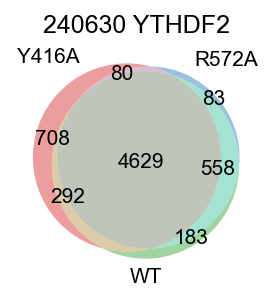

In [29]:
fig,axs=plt.subplots(1,1, figsize=(3,2),dpi=150)
out = venn3(subsets = [Y416A_set,R527A_set,YT_set],
        set_labels=["Y416A","R572A","WT"],
        set_colors=["tab:red","tab:blue","tab:green"],
        alpha=0.45,
        ax=axs)
for text in out.set_labels:
    text.set_fontsize(10)
for text in out.subset_labels:
    if text:
        text.set_fontsize(10)
axs.set_title("240630 YTHDF2")

meta NOT subset; don't know how to subset; dropped


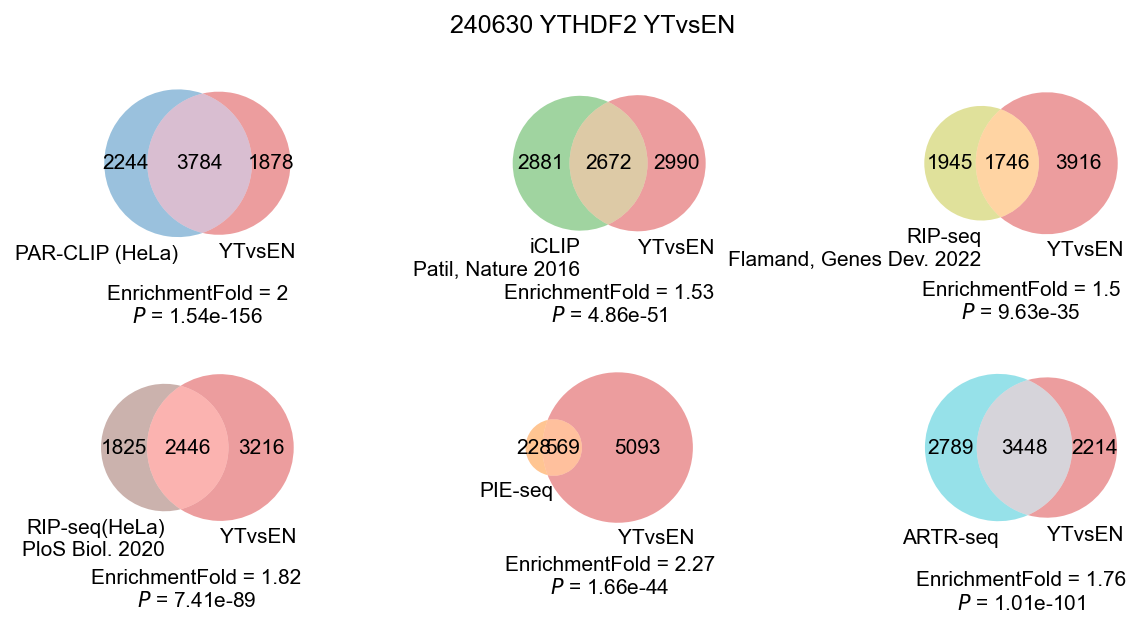

In [26]:
fig,axs=plt.subplots(2,3, figsize=(9,4),dpi=150)
plt.suptitle('240630 YTHDF2 YTvsEN',fontsize=12)
Exporter_venn2(ax=axs[0,0],set_list=[set(df_clip['GENEID'])&keepgeneid,
                       YT_set],
            label_list=['PAR-CLIP (HeLa)','YTvsEN'],color_list=['tab:blue','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[1,0],set_list=[set(df_rip[df_rip['log2(fold_change)'].astype(float)>0]['geneid'])&keepgeneid,
                       YT_set],
            label_list=['RIP-seq(HeLa)\nPloS Biol. 2020','YTvsEN'],color_list=['tab:brown','tab:red'],bgsize=18000)

Exporter_venn2(ax=axs[0,1],set_list=[set(df_iclip['GENEID'])&keepgeneid,
                       YT_set],
            label_list=['iCLIP\nPatil, Nature 2016','YTvsEN'],color_list=['tab:green','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[1,1],set_list=[set(df_pie['GENEID'])&keepgeneid,
                       YT_set],
            label_list=['PIE-seq','YTvsEN'],color_list=['tab:orange','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[0,2],set_list=[set(df_rip2[(df_rip2['log2FoldChange.YTHDF2']>0)&(df_rip2['padj.YTHDF2']<0.05)]['ensembl_gene_id'])&{i.split(".")[0] for i in keepgeneid},
                       {i.split(".")[0] for i in YT_set}],
            label_list=['RIP-seq\nFlamand, Genes Dev. 2022','YTvsEN'],color_list=['tab:olive','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[1,2],set_list=[set(df_artr['GENEID'])&keepgeneid,
                       YT_set],
            label_list=['ARTR-seq','YTvsEN'],color_list=['tab:cyan','tab:red'],bgsize=18000)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.85, hspace=0.6)
plt.savefig("DF2_WTvsEPN_venn.pdf",bbox_inches = 'tight', pad_inches = 0.1)

meta NOT subset; don't know how to subset; dropped


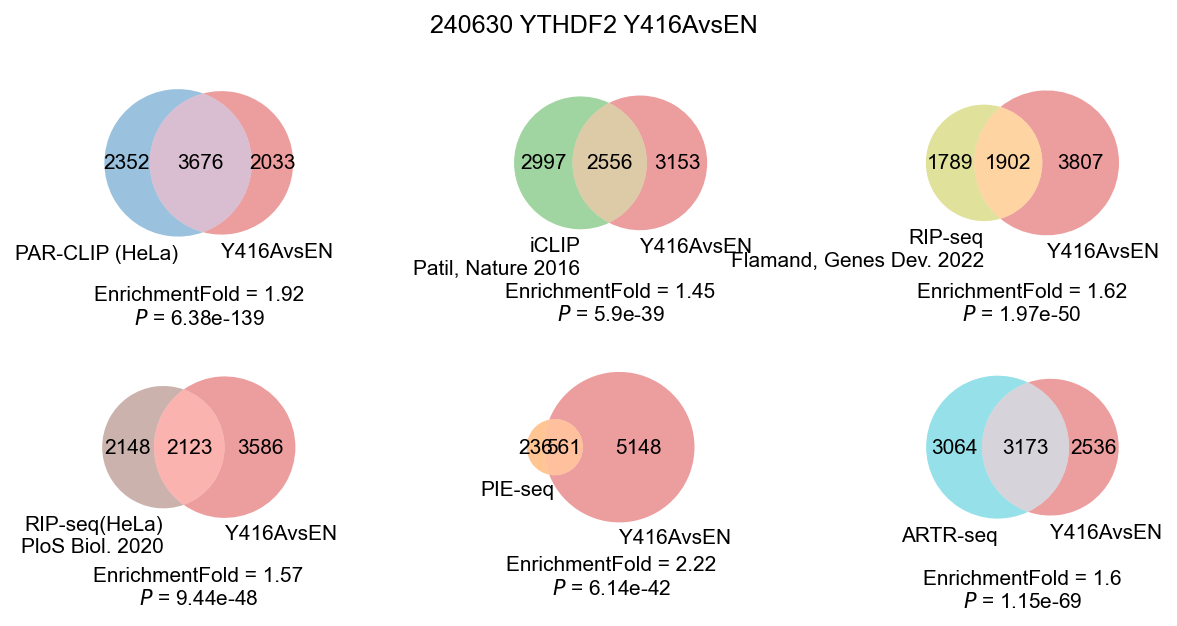

In [30]:
fig,axs=plt.subplots(2,3, figsize=(9,4),dpi=150)
plt.suptitle('240630 YTHDF2 Y416AvsEN',fontsize=12)
Exporter_venn2(ax=axs[0,0],set_list=[set(df_clip['GENEID'])&keepgeneid,
                       Y416A_set],
            label_list=['PAR-CLIP (HeLa)','Y416AvsEN'],color_list=['tab:blue','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[1,0],set_list=[set(df_rip[df_rip['log2(fold_change)'].astype(float)>0]['geneid'])&keepgeneid,
                       Y416A_set],
            label_list=['RIP-seq(HeLa)\nPloS Biol. 2020','Y416AvsEN'],color_list=['tab:brown','tab:red'],bgsize=18000)

Exporter_venn2(ax=axs[0,1],set_list=[set(df_iclip['GENEID'])&keepgeneid,
                       Y416A_set],
            label_list=['iCLIP\nPatil, Nature 2016','Y416AvsEN'],color_list=['tab:green','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[1,1],set_list=[set(df_pie['GENEID'])&keepgeneid,
                       Y416A_set],
            label_list=['PIE-seq','Y416AvsEN'],color_list=['tab:orange','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[0,2],set_list=[set(df_rip2[(df_rip2['log2FoldChange.YTHDF2']>0)&(df_rip2['padj.YTHDF2']<0.05)]['ensembl_gene_id'])&{i.split(".")[0] for i in keepgeneid},
                       {i.split(".")[0] for i in Y416A_set}],
            label_list=['RIP-seq\nFlamand, Genes Dev. 2022','Y416AvsEN'],color_list=['tab:olive','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[1,2],set_list=[set(df_artr['GENEID'])&keepgeneid,
                       Y416A_set],
            label_list=['ARTR-seq','Y416AvsEN'],color_list=['tab:cyan','tab:red'],bgsize=18000)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.85, hspace=0.6)
plt.savefig("DF2_Y416AvsEPN_venn.pdf",bbox_inches = 'tight', pad_inches = 0.1)

meta NOT subset; don't know how to subset; dropped


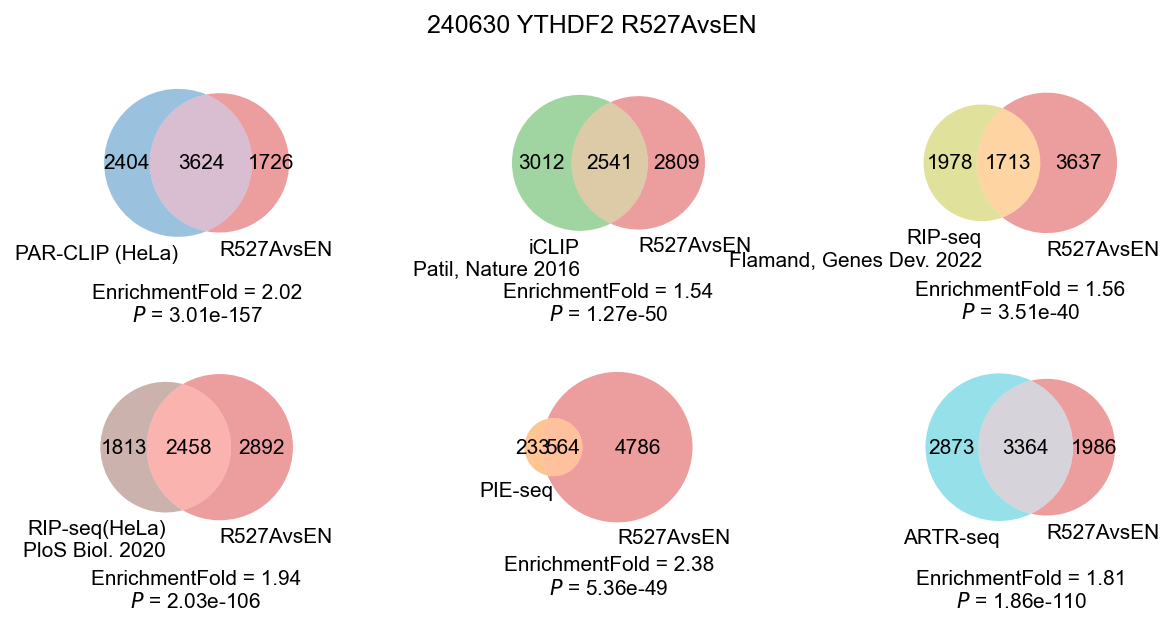

In [31]:
fig,axs=plt.subplots(2,3, figsize=(9,4),dpi=150)
plt.suptitle('240630 YTHDF2 R527AvsEN',fontsize=12)
Exporter_venn2(ax=axs[0,0],set_list=[set(df_clip['GENEID'])&keepgeneid,
                       R527A_set],
            label_list=['PAR-CLIP (HeLa)','R527AvsEN'],color_list=['tab:blue','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[1,0],set_list=[set(df_rip[df_rip['log2(fold_change)'].astype(float)>0]['geneid'])&keepgeneid,
                       R527A_set],
            label_list=['RIP-seq(HeLa)\nPloS Biol. 2020','R527AvsEN'],color_list=['tab:brown','tab:red'],bgsize=18000)

Exporter_venn2(ax=axs[0,1],set_list=[set(df_iclip['GENEID'])&keepgeneid,
                       R527A_set],
            label_list=['iCLIP\nPatil, Nature 2016','R527AvsEN'],color_list=['tab:green','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[1,1],set_list=[set(df_pie['GENEID'])&keepgeneid,
                       R527A_set],
            label_list=['PIE-seq','R527AvsEN'],color_list=['tab:orange','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[0,2],set_list=[set(df_rip2[(df_rip2['log2FoldChange.YTHDF2']>0)&(df_rip2['padj.YTHDF2']<0.05)]['ensembl_gene_id'])&{i.split(".")[0] for i in keepgeneid},
                       {i.split(".")[0] for i in R527A_set}],
            label_list=['RIP-seq\nFlamand, Genes Dev. 2022','R527AvsEN'],color_list=['tab:olive','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[1,2],set_list=[set(df_artr['GENEID'])&keepgeneid,
                       R527A_set],
            label_list=['ARTR-seq','R527AvsEN'],color_list=['tab:cyan','tab:red'],bgsize=18000)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.85, hspace=0.6)
plt.savefig("DF2_R527AvsEPN_venn.pdf",bbox_inches = 'tight', pad_inches = 0.1)

---

In [84]:
df_glori1=pd.read_csv("/wanglab1/gangx/data2/HLF/240314/refclip/GLORI/GSM6432590_293T-mRNA-1_gene.bed",sep="\t",header=None)
df_glori2=pd.read_csv("/wanglab1/gangx/data2/HLF/240314/refclip/GLORI/GSM6432591_293T-mRNA-2_gene.bed",sep="\t",header=None)

In [85]:
df_glori1['GENEID']=df_glori1[9].apply(lambda x:x.split(":")[0])
df_glori2['GENEID']=df_glori2[9].apply(lambda x:x.split(":")[0])

In [86]:
df_glori1=df_glori1[df_glori1[3]!="ELSE"].copy()
df_glori2=df_glori2[df_glori2[3]!="ELSE"].copy()

In [87]:
df_glori2

,0,1,2,3,4,5,6,7,8,9,10,11,GENEID
0,chr10,47498,47499,TUBB8,0.24615,-,chr10,46887,74163,ENSG00000261456.6:TUBB8,protein_coding,-,ENSG00000261456.6
1,chr10,7160000,7160001,SFMBT2,0.58333,-,chr10,7158623,7411488,ENSG00000198879.13:SFMBT2,protein_coding,-,ENSG00000198879.13
2,chr10,7160121,7160122,SFMBT2,0.20000,-,chr10,7158623,7411488,ENSG00000198879.13:SFMBT2,protein_coding,-,ENSG00000198879.13
3,chr10,7160172,7160173,SFMBT2,0.34653,-,chr10,7158623,7411488,ENSG00000198879.13:SFMBT2,protein_coding,-,ENSG00000198879.13
4,chr10,7160202,7160203,SFMBT2,0.55556,-,chr10,7158623,7411488,ENSG00000198879.13:SFMBT2,protein_coding,-,ENSG00000198879.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
209452,chrY,14908026,14908027,MED13P1,0.68750,+,chrY,14907897,14908068,ENSG00000236131.1:MED13P1,processed_pseudogene,+,ENSG00000236131.1
209454,chrY,18387016,18387017,TUBB1P1,0.14286,+,chrY,18386973,18389151,ENSG00000249726.1:TUBB1P1,unprocessed_pseudogene,+,ENSG00000249726.1
209455,chrY,18388376,18388377,TUBB1P1,0.14286,+,chrY,18386973,18389151,ENSG00000249726.1:TUBB1P1,unprocessed_pseudogene,+,ENSG00000249726.1
209456,chrY,18389054,18389055,TUBB1P1,0.82353,+,chrY,18386973,18389151,ENSG00000249726.1:TUBB1P1,unprocessed_pseudogene,+,ENSG00000249726.1


In [88]:
def use_inner_product(a):
    return np.sqrt(np.inner(a, a))

In [331]:
df_glori1[['GENEID',4]].groupby("GENEID").agg({4:use_inner_product})

,4
GENEID,
ENSG00000000003.15,0.494591
ENSG00000000419.14,0.649280
ENSG00000000457.14,2.181767
ENSG00000000460.17,0.692116
ENSG00000001036.14,1.027085
...,...
ENSG00000289694.1,2.101404
ENSG00000289695.1,1.720418
ENSG00000289699.1,1.815619


In [89]:
df_glori=pd.merge(df_glori1[['GENEID',4]].groupby("GENEID").sum(),df_glori2[['GENEID',4]].groupby("GENEID").sum(),left_on="GENEID",right_on="GENEID")

In [348]:
df_glori=pd.merge(df_glori1[['GENEID',4]].groupby("GENEID").agg({4:use_inner_product}),df_glori2[['GENEID',4]].groupby("GENEID").agg({4:use_inner_product}),left_on="GENEID",right_on="GENEID")

In [90]:
df_glori

,4_x,4_y
GENEID,,
ENSG00000000003.15,0.75412,0.79656
ENSG00000000419.14,0.64928,0.76852
ENSG00000000457.14,8.15392,7.18528
ENSG00000000460.17,0.98965,1.44815
ENSG00000001036.14,2.26899,2.18292
...,...,...
ENSG00000289694.1,7.21684,7.37664
ENSG00000289695.1,4.51142,4.31145
ENSG00000289699.1,4.54863,5.29267


In [91]:
df_glori['m6A']=df_glori[['4_x','4_y']].mean(1)

In [128]:
df_glori_plot=pd.merge(df_glori,df_0[~df_0['gene_id'].str.contains("ERCC")],left_on="GENEID",right_on="gene_id",how="right")

In [130]:
df_glori_plot

,4_x,4_y,m6A,gene_id,baseMean,YTvsEN_log2FoldChange,lfcSE,stat,YTvsEN_pvalue,YTvsEN_padj
0,0.60094,0.56915,0.585045,ENSG00000078369.18,2174.669378,7.659980,0.164023,46.700787,0.0,0.0
1,14.95225,14.75095,14.851600,ENSG00000116237.16,4043.313616,9.742179,0.191361,50.909914,0.0,0.0
2,6.18047,6.25775,6.219110,ENSG00000162408.11,1594.779538,8.485932,0.214835,39.499721,0.0,0.0
3,7.04299,6.73376,6.888375,ENSG00000142599.19,762.791878,6.621071,0.173421,38.179087,0.0,0.0
4,0.51221,0.50953,0.510870,ENSG00000074800.16,1982.180008,6.733781,0.133737,50.350981,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
53132,NaN,NaN,NaN,ENSG00000202058.1,0.471625,0.000000,6.120722,0.000000,1.0,1.0
53191,NaN,NaN,NaN,ENSG00000279155.1,0.169713,0.000000,6.120722,0.000000,1.0,NaN
53265,NaN,NaN,NaN,ENSG00000207146.1,0.387117,0.000000,6.120722,0.000000,1.0,1.0
53281,NaN,NaN,NaN,ENSG00000252147.1,0.136167,0.000000,6.120722,0.000000,1.0,NaN


In [111]:
np.percentile(df_glori_plot[df_glori_plot['m6A']>0]['m6A'],(33.33,66.67))

array([1.76602123, 5.77339758])

In [112]:
df_glori_plot['Group']='Middle'
df_glori_plot.loc[df_glori_plot['m6A']>=5.77339758,'Group']='High'
df_glori_plot.loc[df_glori_plot['m6A']<1.76602123 ,'Group']='Low'
df_glori_plot.loc[df_glori_plot['m6A']!=df_glori_plot['m6A'],'Group']="None"

In [113]:
df_glori_plot['Group']=df_glori_plot['Group'].astype("category")
df_glori_plot['Group']=df_glori_plot['Group'].cat.set_categories(["None","Low","Middle","High"])

meta NOT subset; don't know how to subset; dropped


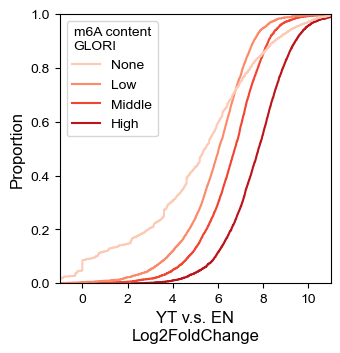

In [98]:
plt.rcParams['figure.figsize'] = (3.5, 3.5)
fig = plt.figure()
fig.tight_layout()
ax=fig.add_subplot(1,1,1)
sns.ecdfplot(data=df_glori_plot,x="YTvsEN_log2FoldChange",hue="Group",palette='Reds',ax=ax)
ax.set_xlim(-1,11)
ax.set_xlabel("YT v.s. EN\nLog2FoldChange",fontsize=12)
ax.set_ylabel("Proportion",fontsize=12)
ax.legend_.set_title("m6A content\nGLORI")
fig.savefig("GLORI_ecdf1.pdf",bbox_inches = 'tight', pad_inches = 0.1)

meta NOT subset; don't know how to subset; dropped


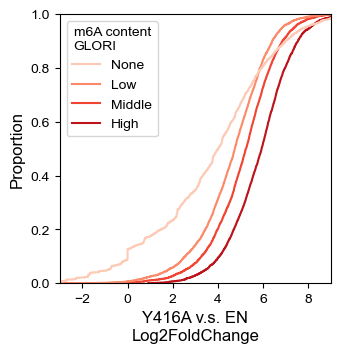

In [107]:
plt.rcParams['figure.figsize'] = (3.5, 3.5)
fig = plt.figure()
fig.tight_layout()
ax=fig.add_subplot(1,1,1)
sns.ecdfplot(data=df_glori_plot,x="Y416AvsEN_log2FoldChange",hue="Group",palette='Reds',ax=ax)
ax.set_xlim(-3,9)
ax.set_xlabel("Y416A v.s. EN\nLog2FoldChange",fontsize=12)
ax.set_ylabel("Proportion",fontsize=12)
ax.legend_.set_title("m6A content\nGLORI")
fig.savefig("GLORI_ecdf2.pdf",bbox_inches = 'tight', pad_inches = 0.1)

meta NOT subset; don't know how to subset; dropped


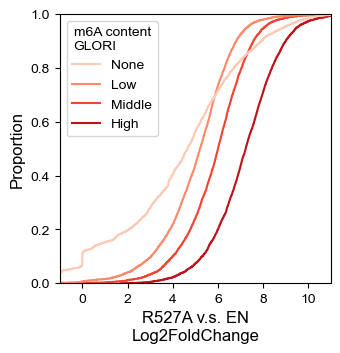

In [117]:
plt.rcParams['figure.figsize'] = (3.5, 3.5)
fig = plt.figure()
fig.tight_layout()
ax=fig.add_subplot(1,1,1)
sns.ecdfplot(data=df_glori_plot,x="R527AvsEN_log2FoldChange",hue="Group",palette='Reds',ax=ax)
ax.set_xlim(-1,11)
ax.set_xlabel("R527A v.s. EN\nLog2FoldChange",fontsize=12)
ax.set_ylabel("Proportion",fontsize=12)
ax.legend_.set_title("m6A content\nGLORI")
fig.savefig("GLORI_ecdf3.pdf",bbox_inches = 'tight', pad_inches = 0.1)